# 1. Environment Setup

Import all necessary libraries including pandas, numpy, scikit-learn for data processing, machine learning, and visualization. Set random seeds for reproducibility.

In [125]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, MinMaxScaler

# Đặt seed để đảm bảo nhất quán giữa các lần chạy
os.environ["PYTHONHASHSEED"] = "42"
np.random.seed(42)
random.seed(42)
print("Seed: 42")

Seed: 42


# 2. Data Processing

## 2.0 Dataset

### Overview
The Cleveland Heart Disease dataset contains 14 clinical features used to predict the presence of heart disease in patients. These are standard measurements taken during cardiac health assessments.<br>
Source: https://www.kaggle.com/datasets/ritwikb3/heart-disease-cleveland
### Feature Descriptions

| Feature | Description |
|---------|-------------|
| **age** | Age in years |
| **sex** | Sex (1 = male; 0 = female) |
| **cp** | Chest pain type: 1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 4 = asymptomatic |
| **trestbps** | Resting blood pressure (mm Hg on hospital admission) |
| **chol** | Serum cholesterol in mg/dL |
| **fbs** | Fasting blood sugar > 120 mg/dL (1 = true; 0 = false) |
| **restecg** | Resting electrocardiographic results: 0 = normal; 1 = ST-T wave abnormality; 2 = probable/definite left ventricular hypertrophy |
| **thalach** | Maximum heart rate achieved |
| **exang** | Exercise-induced angina (1 = yes; 0 = no) |
| **oldpeak** | ST depression induced by exercise relative to rest |
| **slope** | The slope of the peak exercise ST segment: 1 = upsloping; 2 = flat; 3 = downsloping |
| **ca** | Number of major vessels (0-3) colored by fluoroscopy |
| **thal** | Thalassemia: 3 = normal; 6 = fixed defect; 7 = reversible defect |
| **target** | Diagnosis of heart disease: 0 = no disease; 1 = disease present |

### Summary
These 13 features are clinical measurements commonly used by cardiologists to assess heart disease risk. The combination of demographic, symptom-related, and test-based features enables comprehensive cardiac health assessment for predictive modeling.

## 2.1 Data Processing 

### 1. Load dataset 

Download the Cleveland heart disease dataset from Google Drive.

In [126]:
!gdown 16HPyuXWXPptt5g3xvS_kR_wXAfjpR1Ju

Downloading...
From: https://drive.google.com/uc?id=16HPyuXWXPptt5g3xvS_kR_wXAfjpR1Ju
To: /Users/buithanhduy/Desktop/Projects/heart-disease-dianosis/notebooks/cleveland.csv
100%|██████████████████████████████████████| 10.9k/10.9k [00:00<00:00, 13.8MB/s]


Load and preview the raw data to understand its structure.

In [127]:
test=pd.read_csv("cleveland.csv")
test.head(10)

,63,1,1.1,145,233,1.2,2,150,0,2.3,3,0.1,6,0.2
0,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
1,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
2,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
3,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
4,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
5,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,3
6,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
7,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,2
8,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1
9,57,1,4,140,192,0,0,148,0,0.4,2,0.0,6.0,0


Assign column names to the dataset and convert the target variable to binary (0 or 1) where 1 indicates presence of heart disease.

In [128]:
COLUMNS = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 
    'ca', 'thal', 'target'
]
PATH="cleveland.csv"
raw_df = pd.read_csv(PATH, names=COLUMNS)
raw_df["target"] = raw_df["target"].apply(lambda x: 1 if x > 0 else 0)
raw_df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
5,56,1,2,120,236,0,0,178,0,0.8,1,0.0,3.0,0
6,62,0,4,140,268,0,2,160,0,3.6,3,2.0,3.0,1
7,57,0,4,120,354,0,0,163,1,0.6,1,0.0,3.0,0
8,63,1,4,130,254,0,2,147,0,1.4,2,1.0,7.0,1
9,53,1,4,140,203,1,2,155,1,3.1,3,0.0,7.0,1


Separate features into numeric and categorical columns for appropriate preprocessing.

In [129]:
FEATURES=[col for col in raw_df.columns if col != "target"]
numeric_cols=[]
categorical_cols=[]
for col in FEATURES:
    unique_col=raw_df[col].nunique()
    if unique_col>10:
        numeric_cols.append(col)
    else:
        categorical_cols.append(col)
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


### 2. Train Test Splitting

The dataset was split into training, validation, and test sets using an **`80:10:10`** ratio,

In [130]:
X_all=raw_df[FEATURES]
y_all=raw_df["target"]
X_train, X_temp, y_train, y_temp = train_test_split(X_all, y_all, test_size=0.2, stratify=y_all, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [131]:
for c in raw_df.columns:
    raw_df[c] = pd.to_numeric(raw_df[c], errors='coerce')

### 3. Pipeline handling missing data

In [132]:
# Hanlding missing values in categorical columns by most frequent value
cat_proc=Pipeline( 
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        # ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ('scaler', MinMaxScaler())
    ]
)

# Hanlding missing values in numeric columns by median value
num_proc=Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ('scaler', StandardScaler())
    ]
)   

# Combine numeric and categorical pipelines into a single preprocessor
preprocess = ColumnTransformer([
    ('num', num_proc, numeric_cols),
    ('cat', cat_proc, categorical_cols),
], verbose_feature_names_out=False)
preprocess_pipeline=Pipeline(steps=[
    ("preprocess", preprocess)
])

# 3. EDA

## 3.0 Target Quick Check 

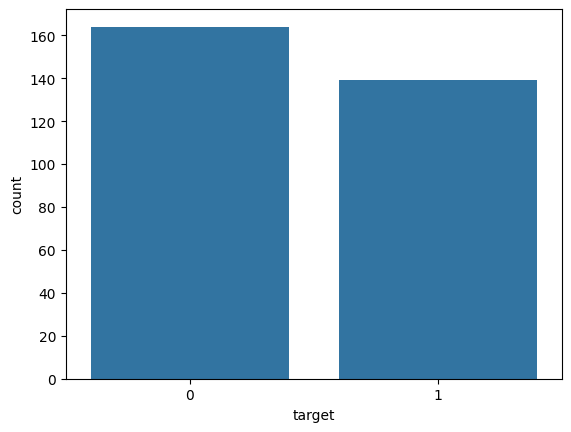

In [133]:
# Create countplot
ax = sns.countplot(x='target', data=raw_df)


### Key Insights
✅ **Well-Balanced Dataset** - The classes are nearly evenly distributed, indicating minimal class imbalance.

✅ **Model Training Advantage** - With balanced classes, we can train ML models without special handling techniques like oversampling, undersampling, or class weight adjustments.

✅ **Fair Evaluation** - The balanced distribution ensures that accuracy and other metrics will be meaningful without being skewed by class prevalence.

## 3.1 Numeric Features

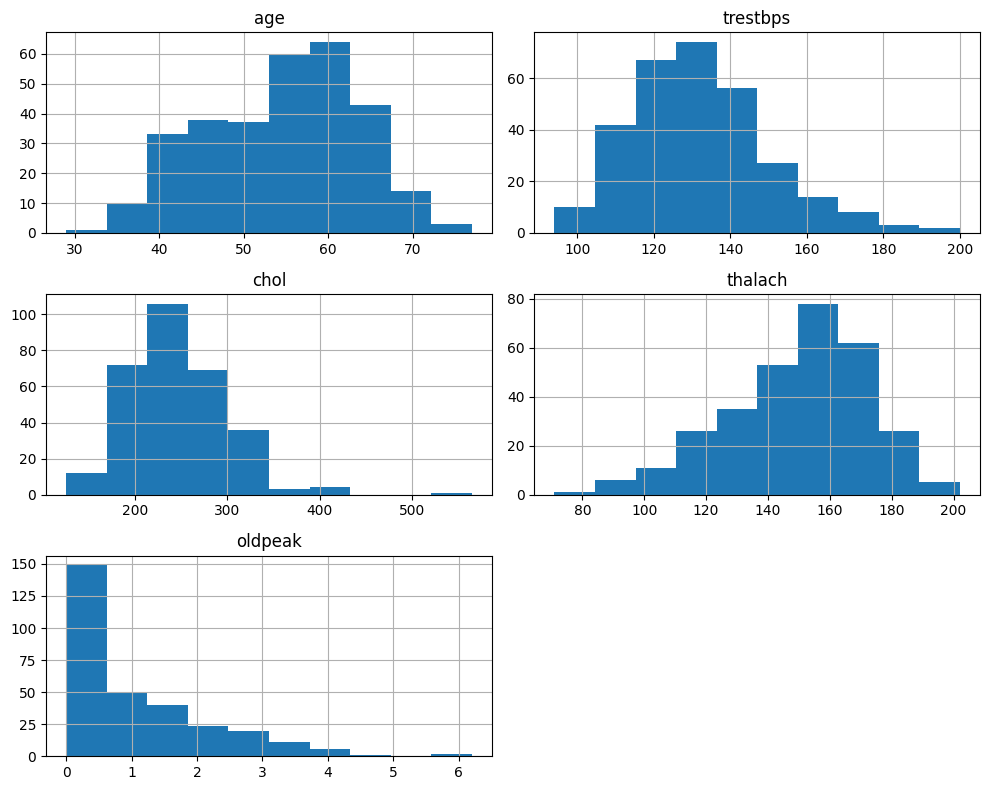

In [134]:
# Plot histograms for numerical columns
raw_df[numeric_cols].hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

### Insights:
* **Age** - Normal distribution, peaks at 55-60 years (middle-aged/older adults)
* **Trestbps** - Normal distribution, centered around 120-130 mm Hg
* **Chol** - Right-skewed with outliers, peaks at 200-250 mg/dL
* **thalach** - thalach appears approximately normally distributed, with a bell-shaped pattern centered around 150–165.
* **Oldpeak** - Heavily right-skewed with >140 patients at 0 (healthy), outliers suggest disease


## 3.2 Categorical Features

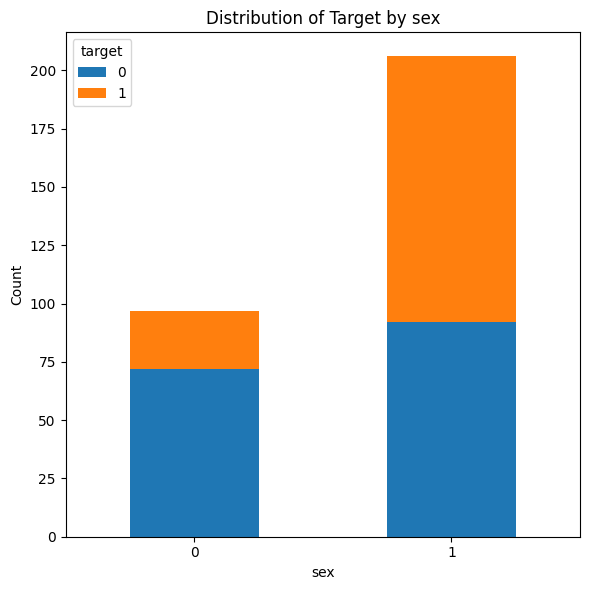

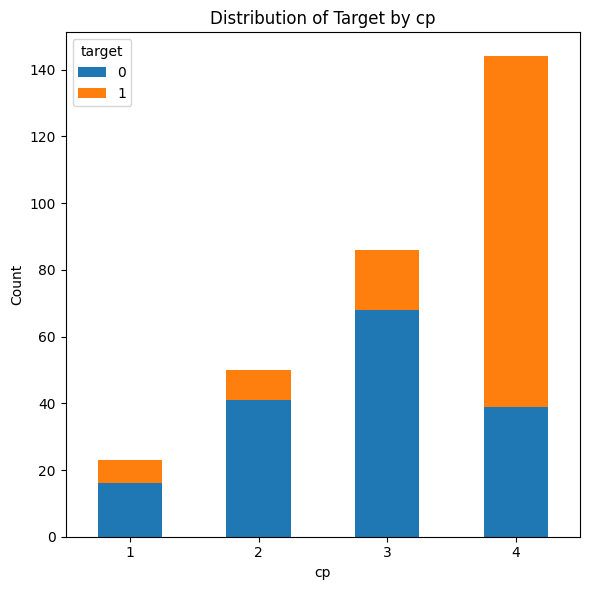

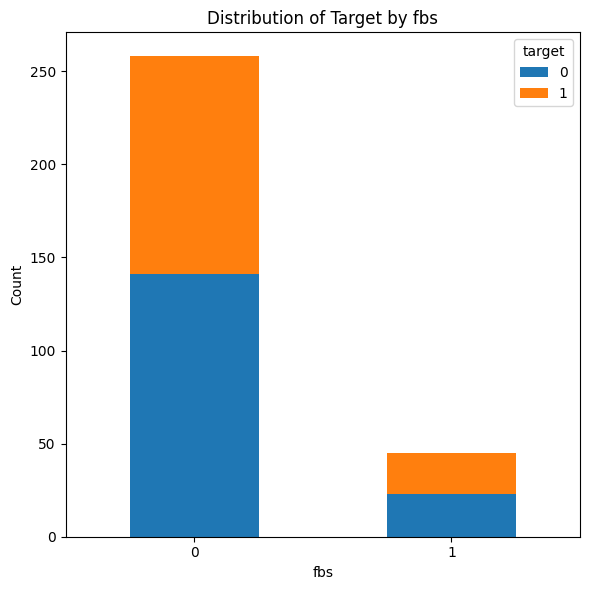

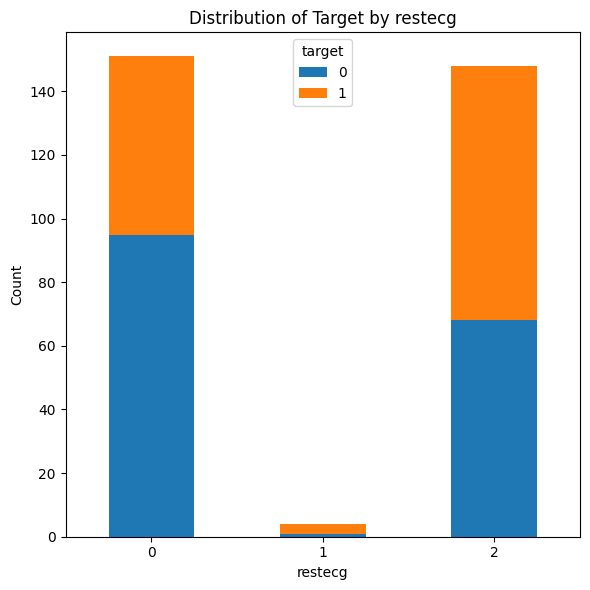

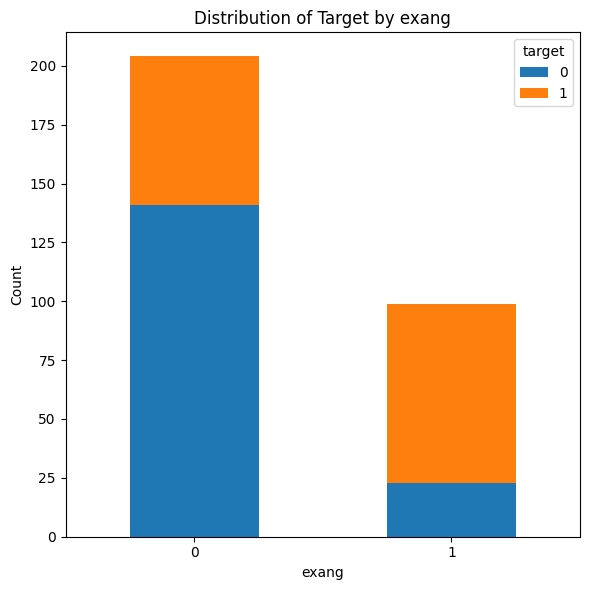

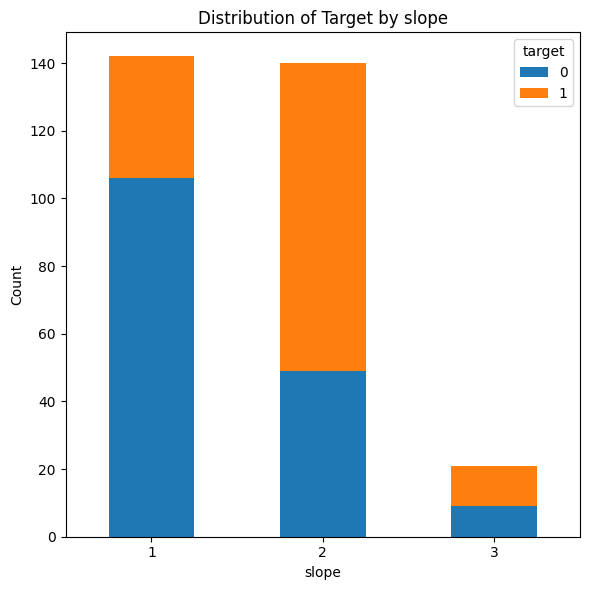

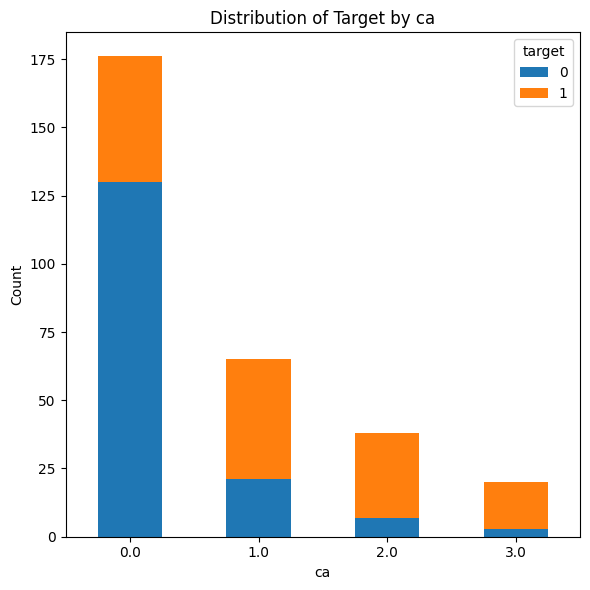

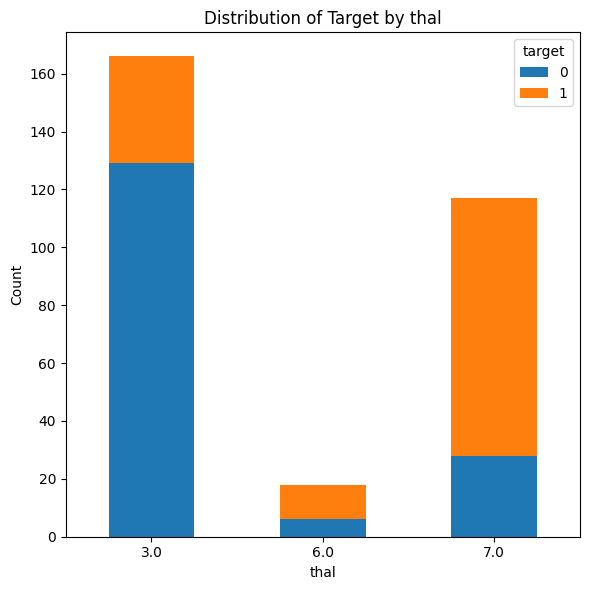

In [135]:
for col in categorical_cols:
    plt.figure(figsize=(6, 6))
    raw_df.groupby([col, 'target']).size().unstack().plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title(f'Distribution of Target by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

### **Insights**: 
- This suggests the dataset has more male samples (`sex` = 1) and that heart disease appears more frequently among males in this sample.
- Chest pain type 4 (`cp` = 4) is most strongly associated with heart disease in this dataset
- High fasting blood sugar(`thal`=7.0) is rare in this dataset and not by itself a strong separator of heart disease status
- This suggests that `restecg` = 2 are dominant and more often associated with heart disease here, while `restecg` = 1 is rare 

# 4. Raw Dataset

## 4.1 Raw dataset

The raw dataset is kept as-is, only preprocessed.

### 1. Handling missing data in raw dataset

In [136]:
X_raw_train=preprocess_pipeline.fit_transform(X_train,y_train)
X_raw_val=preprocess_pipeline.transform(X_val)
X_raw_test=preprocess_pipeline.transform(X_test)

`X_raw_train`, `X_raw_val`, `X_raw_test` is numpy array

### 2. Transform to Dataframe and save to folder 

Get all_features after Pipeline

In [137]:
all_features=list(preprocess_pipeline.named_steps["preprocess"].get_feature_names_out())

Transform np array to dataframe and save to folder 

In [138]:
X_raw_train_df = pd.DataFrame(X_raw_train, columns=all_features, index=X_train.index)
X_raw_test_df = pd.DataFrame(X_raw_test, columns=all_features, index=X_test.index)
X_raw_val_df = pd.DataFrame(X_raw_val, columns=all_features, index=X_val.index)

Save to data folder

In [139]:
from pathlib import Path
import os

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_dir = project_root / "data/raw_dataset"
data_dir.mkdir(parents=True, exist_ok=True)

print("Saving to:", data_dir.resolve())
pd.concat([X_raw_train_df, y_train.rename("target")],
          axis=1).to_csv(data_dir / 'raw_train.csv', index=False)
pd.concat([X_raw_val_df, y_val.rename("target")],
          axis=1).to_csv(data_dir / 'raw_val.csv', index=False)
pd.concat([X_raw_test_df, y_test.rename("target")],
          axis=1).to_csv(data_dir / 'raw_test.csv', index=False)
print("Saved successfully")


Saving to: /Users/buithanhduy/Desktop/Projects/heart-disease-dianosis/data/raw_dataset
Saved successfully


## 4.2 Feature Selection with Decision Tree

### 1. Flow of feature selection with Decision Tree

- Train the tree to predict the target as usual.
- After training, for each split in the tree, record:
    - the feature used for the split
    - the information gain
- Sum up the total gain for each feature across all splits.
- Normalize the values ⇒ you get the feature importance scores.

### 2. Implementation

- Create pipeline Decision Tree Classifier for Feature Selection and fit on X_train 

- Pipeline is only used to fit on train data and find out feature importances

In [140]:
dt_FS_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('decision_tree', DecisionTreeClassifier(random_state=42))
])
dt_FS_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'chol',
                                                   'thalach', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['sex', 'cp', 'fbs',
                                                   'restecg', 'exang', 'slope',
                                                   'ca', 'thal'])],
                                   verbose_feature_names_out=False)),
                ('decision_tree', DecisionTreeClassifier(random_state=42))])

Find out feature importances and select top-K features

In [141]:
sorted_feature_importances=pd.Series(dt_FS_pipeline.named_steps['decision_tree'].feature_importances_, index=all_features).sort_values(ascending=False)
top_K=10
selected_features=sorted_feature_importances.head(top_K).index.tolist()

Get raw dataset with feature selection using decision tree

In [142]:
X_dt_train=X_raw_train_df[selected_features]
X_dt_val=X_raw_val_df[selected_features]
X_dt_test=X_raw_test_df[selected_features]

Save to data folder

In [143]:
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_dir = project_root / "data/raw_dataset"
data_dir.mkdir(parents=True, exist_ok=True)

print("Saving to:", data_dir.resolve())
pd.concat([X_dt_train, y_train.rename("target")],
          axis=1).to_csv(data_dir / 'raw_dt_train.csv', index=False)
pd.concat([X_dt_val, y_val.rename("target")],
          axis=1).to_csv(data_dir / 'raw_dt_val.csv', index=False)
pd.concat([X_dt_test, y_test.rename("target")],
          axis=1).to_csv(data_dir / 'raw_dt_test.csv', index=False)
print("Saved successfully")

Saving to: /Users/buithanhduy/Desktop/Projects/heart-disease-dianosis/data/raw_dataset
Saved successfully


# 5. Feature Engineering Datasets

## 5.1 FE Dataset using Top MI Score for Feature Selection

### 0. Create new features based on given features

Function that includes **adding new feature** for feature interaction 

In [144]:
def add_new_features_func(df):
    df = df.copy()
    if {'chol','age'} <= set(df.columns):
        df['chol_per_age'] = df['chol']/df['age']
    if {'trestbps','age'} <= set(df.columns):
        df['bps_per_age'] = df['trestbps']/df['age']
    if {'thalach','age'} <= set(df.columns):
        df['hr_ratio'] = df['thalach']/df['age']
    if 'age' in df.columns:
        df['age_bin'] = pd.cut(
            df['age'], bins=5, labels=False
        ).astype('category')
    return df

New features that created by `add_new_features_func`

In [145]:
new_num=['chol_per_age','bps_per_age','hr_ratio']
new_cat=['age_bin']
all_nums=numeric_cols+new_num
all_cats=categorical_cols+new_cat

### 1. Preprocessing pipeline 

**Pipeline** handles **missing vales** in cateogrical and numeric columns and **one-hot encoder**

The number of numeric and categorical columns has changed due to `add_new_features_func`

In [146]:
# Hanlding missing values in categorical columns by most frequent value
cat_proc=Pipeline( 
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")) # One-hot encoder for categorical features
    ]
)

# Hanlding missing values in numeric columns by median value
num_proc=Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()) # Standardize numeric features
    ]
)   

# Combine numeric and categorical pipelines into a single preprocessor
preprocess = ColumnTransformer([
    ('num', num_proc, all_nums),
    ('cat', cat_proc, all_cats),
], verbose_feature_names_out=False)

### 2. Feature Interaction 

Create class `AddNewFeaturesTransformer`

In [147]:
class AddNewFeaturesTransformer(
    BaseEstimator,
    TransformerMixin
):
    def __init__(self):
        self.new_features = []
    def fit(self, X, y=None):
        self.columns=X.columns.tolist()
        X_with_new = add_new_features_func(X)
        self.new_features_ = [
            col for col in X_with_new.columns if col not in X.columns
        ]
        return self
    def transform(self, X):
        return add_new_features_func(X) 

Complete Pipeline

In [148]:
fe_preprocess = Pipeline([
    ('add', AddNewFeaturesTransformer()),
    ('pre', preprocess)])

Fit on train dataset

In [149]:
X_fe_train=fe_preprocess.fit_transform(X_train, y_train)
X_fe_test=fe_preprocess.transform(X_test)
X_fe_val=fe_preprocess.transform(X_val)

Get full features

In [167]:
full_features = [
    f.replace("num__", "").replace("cat__", "")
    for f in fe_preprocess.named_steps["pre"].get_feature_names_out()
]

Convert into data frame

In [151]:
X_fe_train_df = pd.DataFrame(X_fe_train, columns=full_features, index=X_train.index)
X_fe_test_df = pd.DataFrame(X_fe_test, columns=full_features, index=X_test.index)
X_fe_val_df = pd.DataFrame(X_fe_val, columns=full_features, index=X_val.index)

In [152]:
X_fe_train_df.head()

,age,trestbps,chol,thalach,oldpeak,chol_per_age,bps_per_age,hr_ratio,sex_0.0,sex_1.0,...,ca_2.0,ca_3.0,thal_3.0,thal_6.0,thal_7.0,age_bin_0.0,age_bin_1.0,age_bin_2.0,age_bin_3.0,age_bin_4.0
180,-0.729485,-0.395692,0.458139,0.708371,-0.445445,0.952258,0.272980,0.726265,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
208,0.050166,-0.054513,0.230598,0.222495,-0.891627,0.082082,-0.199285,-0.054469,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
167,-0.061212,0.059213,0.723605,0.399178,-0.891627,0.606839,-0.025578,0.099522,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
105,-0.061212,-1.305501,1.121803,0.266666,-0.891627,0.965051,-0.980964,0.031766,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
297,0.272924,0.514117,-0.167601,-1.190962,-0.713154,-0.411237,-0.000436,-0.859761,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


### 3. Mutual Information Score

In [153]:
numeric_features=fe_preprocess.named_steps["pre"].named_transformers_['num'].get_feature_names_out(all_nums)
len(numeric_features)

8

In [154]:
discrete_features=fe_preprocess.named_steps["pre"].named_transformers_['cat'].named_steps["encoder"].get_feature_names_out(all_cats)
is_discrete = np.array(
    [c in discrete_features for c in full_features],
    dtype=bool
)

**Calculate mutal information score** so we need to figure out some parameters: 
`mutual_info_classif(X_fe_train, y_train.values, discrete_features)`
- `X_fe_train`, `y_train.values`, `is_discrete`
- `X_fe_train`, `y_train.values` are available
- `is_discrete` is the boolean np array that indicates whether feature is num or cat

In [155]:
# Calculte mi scores for all features and it returns the np array of all mi scores corresponding to the order of full_features
mi = mutual_info_classif(X_fe_train, y_train.values, random_state=42, discrete_features=is_discrete)

# Create a Series to hold the MI scores with feature names as index, and sort it in descending order
mi_scores=pd.Series(
    mi, index=full_features).sort_values(ascending=False)
mi_scores.head(13)

thal_3.0     0.153931
thal_7.0     0.139648
cp_4.0       0.123592
ca_0.0       0.108158
exang_1.0    0.091101
exang_0.0    0.091101
oldpeak      0.089110
slope_1.0    0.069772
chol         0.063270
slope_2.0    0.059589
thalach      0.059076
hr_ratio     0.053391
sex_0.0      0.049642
dtype: float64

**Visualize mi_scores on a bar chart**

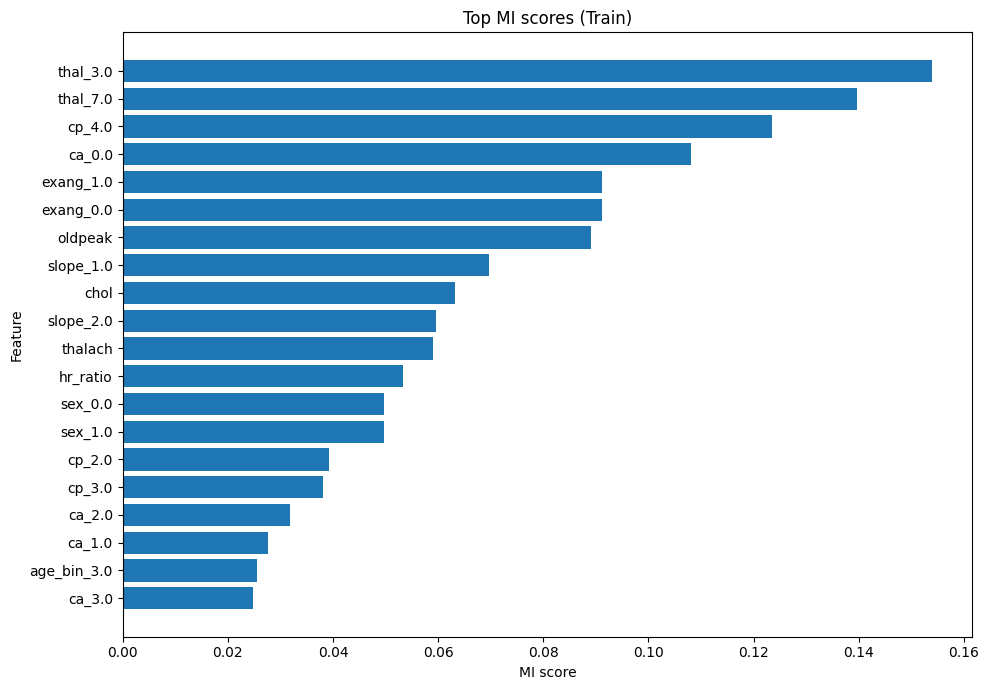

In [156]:
plt.figure(figsize=(10, max(6, 0.35*20)))
plt.barh(mi_scores[:20][::-1].index, mi_scores[:20][::-1].values)
plt.title('Top MI scores (Train)')
plt.xlabel('MI score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Select `top_K` valuable features 

In [157]:
top_K_feature = list(mi_scores.index[:13])
top_K_feature # np array of top 13 features based on MI scores

['thal_3.0',
 'thal_7.0',
 'cp_4.0',
 'ca_0.0',
 'exang_1.0',
 'exang_0.0',
 'oldpeak',
 'slope_1.0',
 'chol',
 'slope_2.0',
 'thalach',
 'hr_ratio',
 'sex_0.0']

In [158]:
X_fe_train_df=X_fe_train_df[top_K_feature].assign(target=y_train.values)
X_fe_val_df=X_fe_val_df[top_K_feature].assign(target=y_val.values)
X_fe_test_df=X_fe_test_df[top_K_feature].assign(target=y_test.values)
len(X_fe_train_df)

242

**Save into data folder**

In [159]:
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_dir = project_root / "data/FE_dataset"
data_dir.mkdir(parents=True, exist_ok=True)

print("Saving to:", data_dir.resolve())
X_fe_train_df.to_csv(data_dir / 'fe_train.csv', index=False)
X_fe_val_df.to_csv(data_dir / 'fe_val.csv', index=False)
X_fe_test_df.to_csv(data_dir / 'fe_test.csv', index=False)
print("Saved successfully")

Saving to: /Users/buithanhduy/Desktop/Projects/heart-disease-dianosis/data/FE_dataset
Saved successfully


## 5.2 FE Dataset using Decision Tree for Feature Selection 

At this time, we want to preprocessing and fit on decision tree again 

### 1. Create Pipeline for decision tree and preprocessing

**At this time, we want to fit pipeline on train data again** 

In [160]:
# Pipeline columns for feature selection using decision tree
FE_DT_FS_pipeline = Pipeline([
    ('fe_preprocess', fe_preprocess),
    ('decision_tree', DecisionTreeClassifier(random_state=42))
])

# Fit the pipeline to the training data
FE_DT_FS_pipeline.fit(X_train, y_train)
X_fe_train = FE_DT_FS_pipeline.named_steps["fe_preprocess"].transform(X_train)
X_fe_test = FE_DT_FS_pipeline.named_steps["fe_preprocess"].transform(X_test)
X_fe_val = FE_DT_FS_pipeline.named_steps["fe_preprocess"].transform(X_val)

**Convert to dataframe**

In [161]:
X_fe_train_df = pd.DataFrame(X_fe_train, columns=full_features, index=X_train.index)
X_fe_test_df = pd.DataFrame(X_fe_test, columns=full_features, index=X_test.index)
X_fe_val_df = pd.DataFrame(X_fe_val, columns=full_features, index=X_val.index)

### 2. Get feature importances

In [162]:
FE_DT_FS_pipeline.named_steps['decision_tree'].feature_importances_

array([0.03371747, 0.00182816, 0.04899304, 0.01550552, 0.05197161,
       0.07921643, 0.01135263, 0.06596666, 0.02059521, 0.        ,
       0.        , 0.        , 0.02579603, 0.11794914, 0.00264307,
       0.        , 0.        , 0.        , 0.        , 0.02908492,
       0.01331408, 0.02501433, 0.        , 0.        , 0.10538809,
       0.        , 0.        , 0.        , 0.29292053, 0.        ,
       0.        , 0.00985417, 0.        , 0.01604822, 0.02392502,
       0.00891568])

**Sort feature importance and get top 10 valuable features**

In [163]:
# Sort feature importances and get the corresponding feature names
sorted_feature_importances=pd.Series(FE_DT_FS_pipeline.named_steps['decision_tree'].feature_importances_, index=full_features).sort_values(ascending=False)

# Get top 10 features based on feature importance
selected_features=sorted_feature_importances.head(10).index.tolist()

**Visualization**

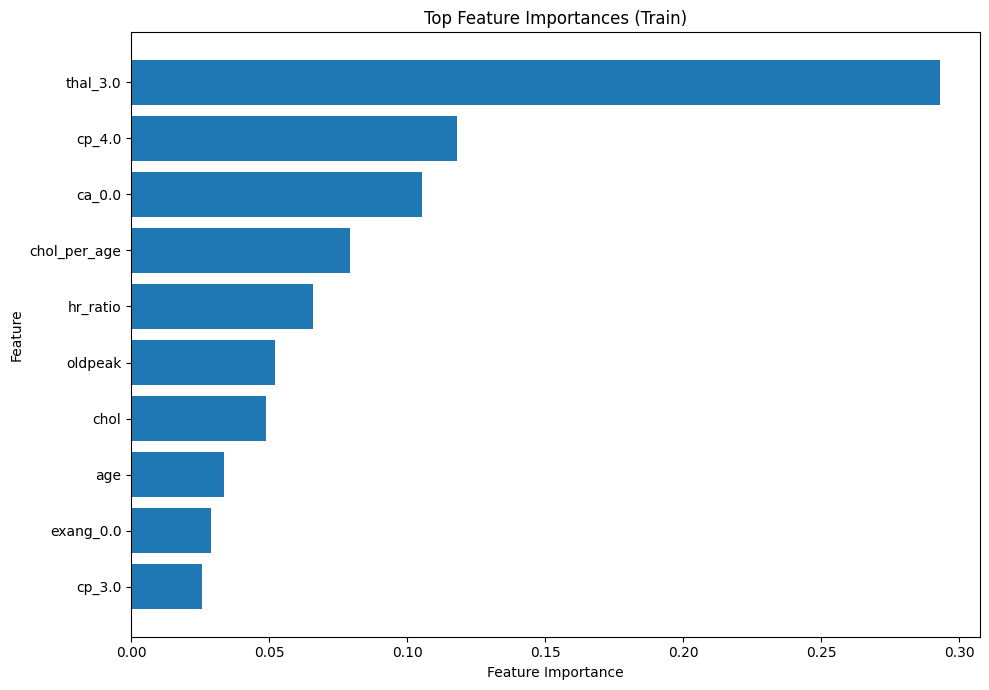

In [164]:
plt.figure(figsize=(10, max(6, 0.35*20)))
plt.barh(sorted_feature_importances.head(10)[::-1].index, sorted_feature_importances.head(10)[::-1].values)
plt.title('Top Feature Importances (Train)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

**Complete dataframe with selected features that were got by decision tree**

In [165]:
X_fe_train_df=X_fe_train_df[selected_features].assign(target=y_train.values)
X_fe_val_df=X_fe_val_df[selected_features].assign(target=y_val.values)
X_fe_test_df=X_fe_test_df[selected_features].assign(target=y_test.values)

### 3. Save into folder

In [166]:
from pathlib import Path
import os

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

data_dir = project_root / "data/FE_dataset"
data_dir.mkdir(parents=True, exist_ok=True)

print("Saving to:", data_dir.resolve())
X_fe_train_df.to_csv(data_dir / 'fe_dt_train.csv', index=False)
X_fe_val_df.to_csv(data_dir / 'fe_dt_val.csv', index=False)
X_fe_test_df.to_csv(data_dir / 'fe_dt_test.csv', index=False)
print("Saved successfully")


Saving to: /Users/buithanhduy/Desktop/Projects/heart-disease-dianosis/data/FE_dataset
Saved successfully
